# **🔍 Exploración Inicial**

## **📚 Librerías**

In [1]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

In [2]:
# Gráficos interactivos en el editor y PNG estático para GitHub y el informe
pio.renderers.default = 'plotly_mimetype+png'
pio.templates.default = 'plotly_white'

COLOR_PRINCIPAL = '#2a78d6'
COLORES_CLASE = {'Legítima': '#2a78d6', 'Fraude': '#eb6834'}
ETIQUETAS_CLASE = {0: 'Legítima', 1: 'Fraude'}
NUMERO_BINS = 50

In [3]:
# Funciones auxiliares para graficar distribuciones.
# Los bins se calculan con numpy y solo se grafican los conteos: pasarle a plotly las
# 150k filas crudas embebe todos los datos en el notebook y lo vuelve enorme


def umbral_escala_log(serie):
    """Umbral de la escala log simétrica: percentil 1 de los valores absolutos distintos de cero."""
    absolutos = serie.abs()
    return absolutos[absolutos > 0].quantile(0.01)


def transformar_escala(serie, umbral):
    """Escala log simétrica: casi lineal por debajo del umbral, logarítmica en las colas y admite negativos."""
    return np.sign(serie) * np.log10(1 + serie.abs() / umbral)


def ticks_escala_log(serie, umbral):
    """Ubica los ticks en potencias de 10 para leer el eje en las unidades originales."""
    exponentes = range(int(np.floor(np.log10(umbral))), int(np.ceil(np.log10(serie.abs().max()))) + 1)
    potencias = [10.0 ** exponente for exponente in exponentes]
    valores = [0.0] + [potencia for potencia in potencias if potencia <= serie.max()]
    valores += [-potencia for potencia in potencias if -potencia >= serie.min()]
    textos = [f'{valor:,.0f}' if abs(valor) >= 1 else f'{valor:g}' for valor in valores]
    return transformar_escala(pd.Series(valores), umbral).tolist(), textos


def conteo_por_bin(serie, bordes):
    """Cuenta los valores no nulos de una serie en cada bin y devuelve el centro de cada uno."""
    conteos, _ = np.histogram(serie.dropna(), bins=bordes)
    return pd.DataFrame({'centro': (bordes[:-1] + bordes[1:]) / 2, 'conteo': conteos})


def preparar_valores(serie, usar_log):
    """Transforma la serie si es de cola larga y devuelve los ticks del eje en unidades originales."""
    if not usar_log:
        return serie, {'title_text': serie.name}
    umbral = umbral_escala_log(serie)
    posiciones, textos = ticks_escala_log(serie.dropna(), umbral)
    formato_eje = {'title_text': f'{serie.name} (escala log)', 'tickvals': posiciones, 'ticktext': textos}
    return transformar_escala(serie, umbral), formato_eje


def graficar_distribucion(serie, usar_log):
    """Histograma y boxplot agregados de una variable continua."""
    valores, formato_eje = preparar_valores(serie.dropna(), usar_log)
    histograma = conteo_por_bin(valores, np.histogram_bin_edges(valores, bins=NUMERO_BINS))
    primer_cuartil, mediana, tercer_cuartil = valores.quantile([0.25, 0.5, 0.75])
    rango_intercuartil = tercer_cuartil - primer_cuartil

    fig = make_subplots(rows=1, cols=2, column_widths=[0.8, 0.2], horizontal_spacing=0.08)
    fig.add_trace(
        go.Bar(x=histograma['centro'], y=histograma['conteo'], marker_color=COLOR_PRINCIPAL),
        row=1, col=1,
    )
    fig.add_trace(
        go.Box(
            x=[serie.name],
            q1=[primer_cuartil],
            median=[mediana],
            q3=[tercer_cuartil],
            lowerfence=[max(valores.min(), primer_cuartil - 1.5 * rango_intercuartil)],
            upperfence=[min(valores.max(), tercer_cuartil + 1.5 * rango_intercuartil)],
            marker_color=COLOR_PRINCIPAL,
        ),
        row=1, col=2,
    )
    fig.update_xaxes(**formato_eje, row=1, col=1)
    fig.update_yaxes(title_text='Transacciones', row=1, col=1)
    formato_eje.pop('title_text')
    fig.update_yaxes(**formato_eje, row=1, col=2)
    fig.update_layout(
        title=f'Distribución de {serie.name}', bargap=0, showlegend=False, height=350,
    )
    return fig


def graficar_distribucion_por_clase(serie, clases, usar_log):
    """Histograma agregado de una variable continua, normalizado dentro de cada clase."""
    valores, formato_eje = preparar_valores(serie, usar_log)
    bordes = np.histogram_bin_edges(valores.dropna(), bins=NUMERO_BINS)

    fig = go.Figure()
    for nombre_clase, color in COLORES_CLASE.items():
        histograma = conteo_por_bin(valores[clases == nombre_clase], bordes)
        fig.add_trace(go.Bar(
            x=histograma['centro'],
            y=histograma['conteo'] / histograma['conteo'].sum() * 100,
            name=nombre_clase,
            marker_color=color,
            opacity=0.6,
        ))
    fig.update_xaxes(**formato_eje)
    fig.update_layout(
        title=f'Distribución de {serie.name} por clase',
        yaxis_title='% dentro de la clase',
        legend_title_text='Clase',
        barmode='overlay',
        bargap=0,
        height=350,
    )
    return fig

## **🔢 Datos**

In [4]:
# Carga del dataset crudo del challenge
df = pd.read_csv('../data/raw/dataset.csv')

## **🧾 Panorama general**

In [5]:
# Dimensiones del dataset: (filas, columnas)
df.shape

(150000, 19)

In [6]:
# Primeras filas para ver el formato de cada columna
df.head()

,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0


In [7]:
# Tipos de dato y conteo de valores no nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   a       150000 non-null  int64  
 1   b       137016 non-null  float64
 2   c       137016 non-null  float64
 3   d       149635 non-null  float64
 4   e       150000 non-null  float64
 5   f       149989 non-null  float64
 6   g       149806 non-null  str    
 7   h       150000 non-null  int64  
 8   j       150000 non-null  str    
 9   k       150000 non-null  float64
 10  l       149989 non-null  float64
 11  m       149635 non-null  float64
 12  n       150000 non-null  int64  
 13  o       41143 non-null   str    
 14  p       150000 non-null  str    
 15  fecha   150000 non-null  str    
 16  monto   150000 non-null  float64
 17  score   150000 non-null  int64  
 18  fraude  150000 non-null  int64  
dtypes: float64(9), int64(5), str(5)
memory usage: 21.7 MB


In [8]:
# Cantidad y porcentaje de nulos, solo para columnas que tienen alguno
nulos = pd.DataFrame({
    'nulos': df.isna().sum(),
    'porcentaje': df.isna().mean().mul(100).round(2),
})
nulos[nulos['nulos'] > 0].sort_values('nulos', ascending=False)

,nulos,porcentaje
o,108857,72.57
b,12984,8.66
c,12984,8.66
d,365,0.24
m,365,0.24
g,194,0.13
f,11,0.01
l,11,0.01


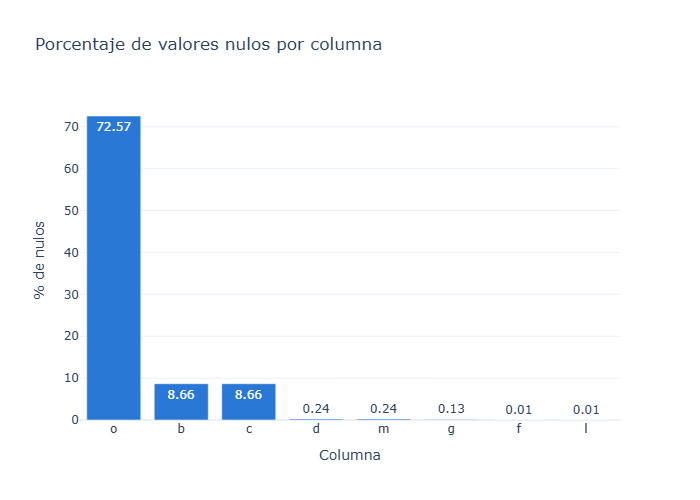

In [9]:
# Porcentaje de nulos por columna
fig = px.bar(
    nulos[nulos['nulos'] > 0].sort_values('porcentaje', ascending=False),
    y='porcentaje',
    text='porcentaje',
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'index': 'Columna', 'porcentaje': '% de nulos'},
    title='Porcentaje de valores nulos por columna',
)
fig.show()

In [10]:
# Filas completamente duplicadas
df.duplicated().sum()

np.int64(0)

**💡 Hallazgos**

- El dataset tiene **150.000 transacciones y 19 columnas**, sin filas duplicadas. Las variables `a`–`p` vienen anonimizadas, así que su significado hay que inferirlo del comportamiento.
- Los nulos aparecen en **pares exactos**: `b`/`c` (8,66%), `d`/`m` (0,24%) y `f`/`l` (0,01%) son nulos siempre en las mismas filas. Esto sugiere que cada par proviene de una misma fuente o consulta, y que cuando esa fuente falla se pierden ambas.
- `o` tiene **72,6% de nulos**. Con esa proporción, más que un dato faltante parece una respuesta de tipo "no aplica", así que conviene evaluar si el nulo es informativo antes de imputarlo.
- `fecha` se carga como texto y habrá que convertirla a `datetime`.

## **🎯 Variable objetivo**

In [11]:
# Conteo de transacciones legítimas (0) y fraudulentas (1)
df['fraude'].value_counts()

fraude
0    142500
1      7500
Name: count, dtype: int64

In [12]:
# Proporción de cada clase en porcentaje, para dimensionar el desbalance
df['fraude'].value_counts(normalize=True).mul(100).round(2)

fraude
0    95.0
1     5.0
Name: proportion, dtype: float64

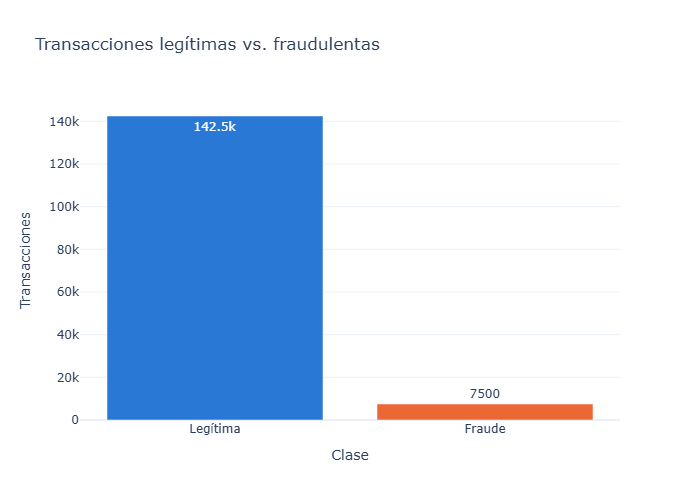

In [13]:
# Distribución de clases
conteo_clases = (
    df['fraude'].map(ETIQUETAS_CLASE)
    .value_counts()
    .rename_axis('Clase')
    .reset_index(name='Transacciones')
)

fig = px.bar(
    conteo_clases,
    x='Clase',
    y='Transacciones',  
    color='Clase',
    text_auto=True,
    color_discrete_map=COLORES_CLASE,
    title='Transacciones legítimas vs. fraudulentas',
)
fig.update_layout(showlegend=False)
fig.show()

**💡 Hallazgos**

- Hay **7.500 fraudes sobre 150.000 transacciones: exactamente 5%**. Una proporción tan redonda sugiere que el dataset fue muestreado. La tasa real en producción podría ser distinta, lo que afectaría la calibración de las probabilidades y el umbral de decisión.
- El desbalance es de **19 a 1**: un modelo que aprueba todo tendría 95% de accuracy sin detectar un solo fraude. La evaluación debe centrarse en la clase minoritaria y, sobre todo, en la **ganancia** definida en el enunciado (25% por transacción legítima aprobada, −100% del monto por fraude aprobado).

## **📊 Distribuciones**

In [14]:
# Estadísticos descriptivos de las variables numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
a,150000.0,3.705407,0.753206,1.000000,4.000000,4.000000,4.000000,4.000000e+00
b,137016.0,0.728115,0.132943,0.000000,0.678400,0.755500,0.806500,1.000000e+00
c,137016.0,260445.107044,846436.141626,0.160000,9679.915000,43711.655000,145443.627500,1.387874e+07
d,149635.0,21.677669,20.062146,0.000000,2.000000,14.000000,50.000000,5.000000e+01
e,150000.0,0.220641,2.434995,0.000000,0.000000,0.104875,0.282938,8.333333e+02
f,149989.0,51.169352,709.472904,-5.000000,1.000000,8.000000,33.000000,1.452740e+05
h,150000.0,14.193513,14.161216,0.000000,3.000000,9.000000,21.000000,5.800000e+01
k,150000.0,0.497532,0.288348,0.000004,0.246819,0.495990,0.746508,9.999948e-01
l,149989.0,2305.409403,1712.379601,0.000000,910.000000,1937.000000,3445.000000,7.544000e+03
m,149635.0,299.969579,321.075806,0.000000,42.000000,193.000000,459.000000,2.225000e+03


In [15]:
# Clasificación de las variables numéricas: discretas (pocos valores) y continuas.
# Las continuas con asimetría > 5 se consideran de cola larga y se grafican en escala log
columnas_numericas = df.select_dtypes(include='number').columns.drop('fraude')
columnas_discretas = [columna for columna in columnas_numericas if df[columna].nunique() <= 10]
columnas_continuas = columnas_numericas.drop(columnas_discretas)
columnas_cola_larga = df[columnas_continuas].skew().loc[lambda asimetria: asimetria > 5].index

print('Discretas:', columnas_discretas)
print('Continuas:', list(columnas_continuas))
print('Cola larga:', list(columnas_cola_larga))

Discretas: ['a', 'n']
Continuas: ['b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'monto', 'score']
Cola larga: ['c', 'e', 'f', 'monto']


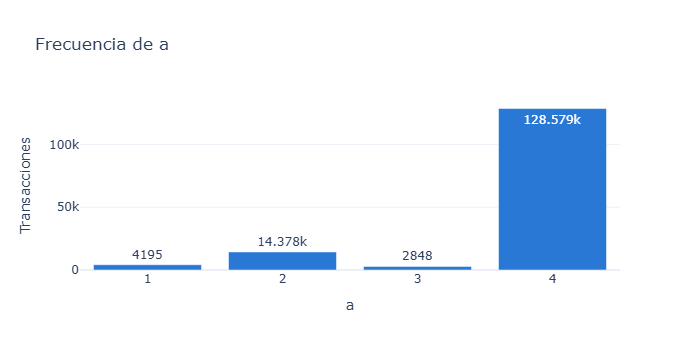

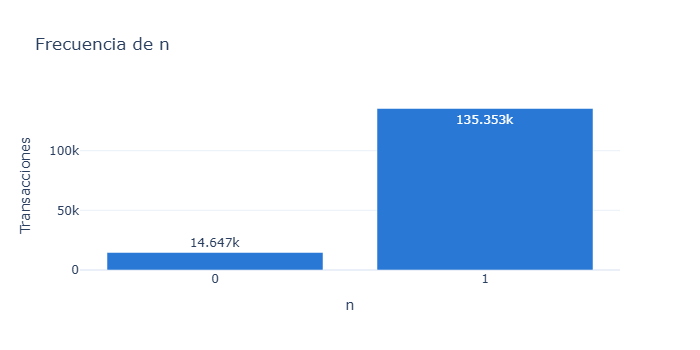

In [16]:
# Frecuencia de cada valor en las variables numéricas discretas
for columna in columnas_discretas:
    fig = px.bar(
        df[columna].value_counts().sort_index(),
        text_auto=True,
        color_discrete_sequence=[COLOR_PRINCIPAL],
        labels={columna: columna, 'value': 'Transacciones'},
        title=f'Frecuencia de {columna}',
    )
    fig.update_xaxes(type='category')
    fig.update_layout(showlegend=False, height=350)
    fig.show()

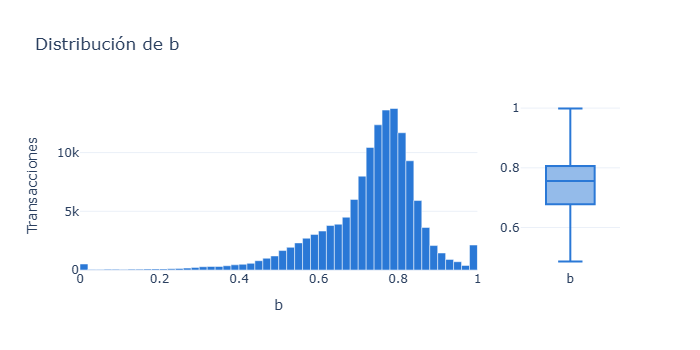

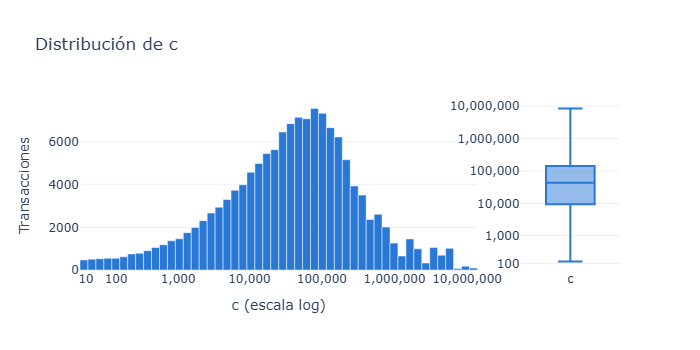

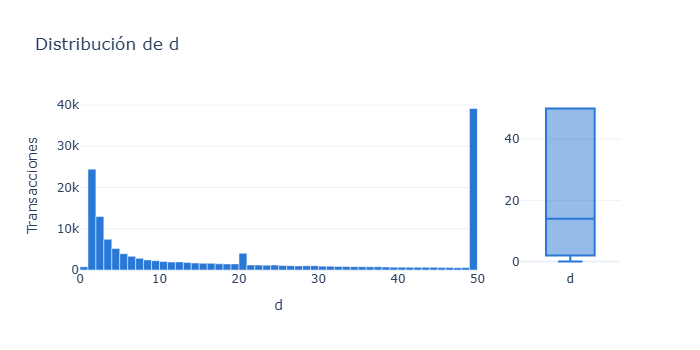

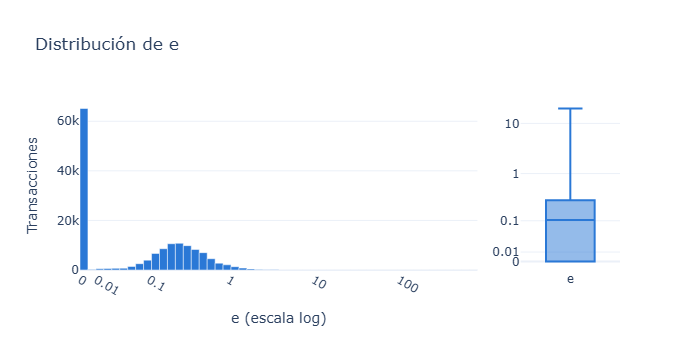

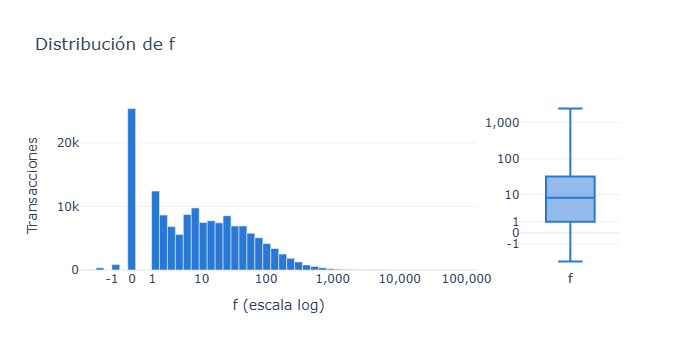

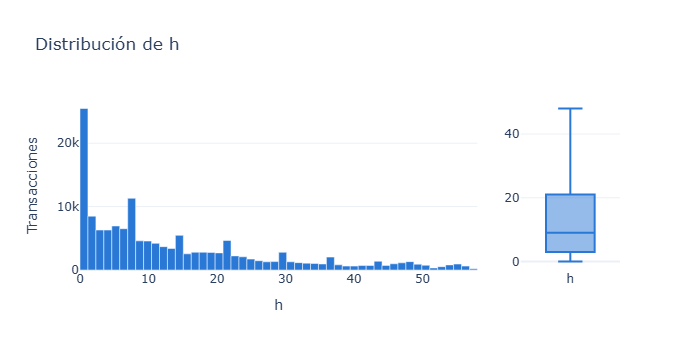

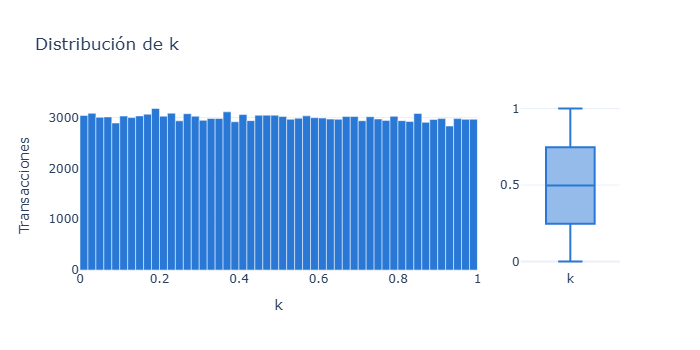

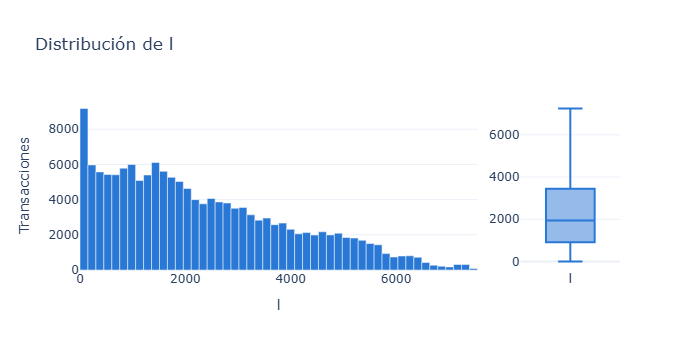

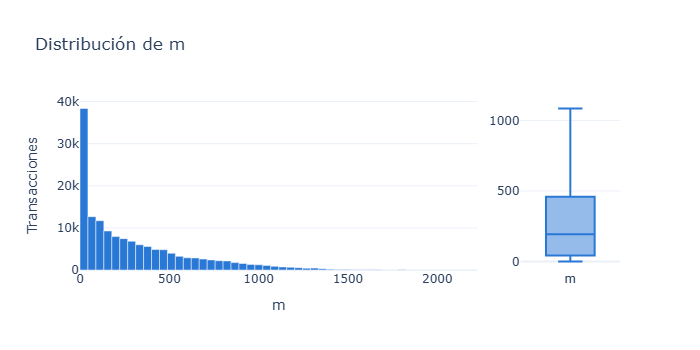

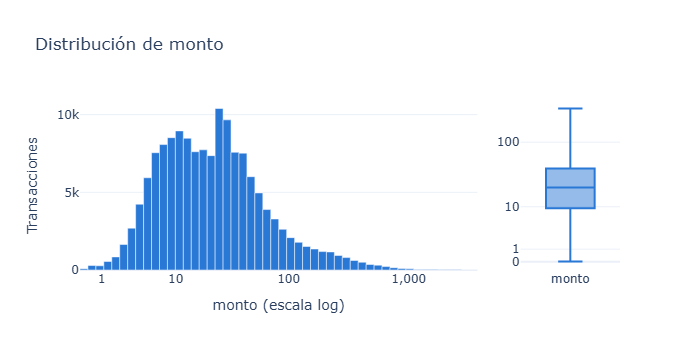

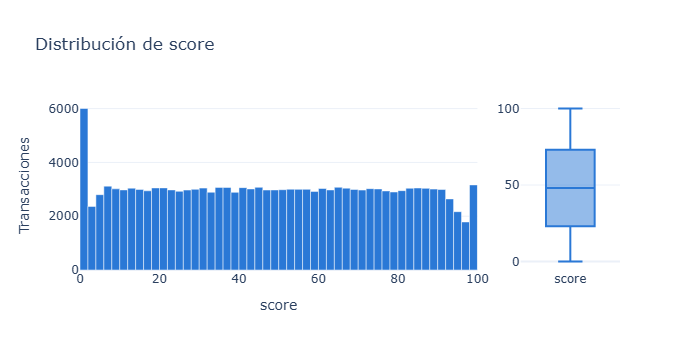

In [17]:
# Histograma y boxplot de cada variable continua, sin recortar outliers
for columna in columnas_continuas:
    graficar_distribucion(df[columna], usar_log=columna in columnas_cola_larga).show()

**💡 Hallazgos**

- `a` y `n` son **discretas**: `a` toma 4 valores y se concentra en `4` (~86%), y `n` es binaria con ~90% en `1`.
- `score` (0–100) y `k` (0–1) tienen distribuciones **prácticamente uniformes**. `k` tiene un valor distinto por fila, así que podría ser un identificador o un número aleatorio normalizado, y conviene verificar si aporta algo frente a fraude.
- `d` va de 0 a 50 y acumula cerca de **un cuarto de los registros en el tope (50)**. Parece una variable truncada, donde 50 significaría "50 o más".
- `c`, `e`, `f` y `monto` tienen **cola larga** (asimetría > 5). En escala log, `c` y `monto` son aproximadamente log-normales. `e` tiene una gran masa de **ceros exactos** separada del resto, y `f` tiene un pico en 0 y algunos **valores negativos** (−1 a −5) que podrían ser códigos especiales más que cantidades.
- Para modelos lineales convendrá transformar las variables de cola larga; los modelos basados en árboles no lo necesitan.

In [18]:
# Cardinalidad (valores únicos) de las variables no numéricas
columnas_categoricas = df.select_dtypes(exclude='number').columns
df[columnas_categoricas].nunique().sort_values()

p             2
o             2
g            51
j          8324
fecha    145813
dtype: int64

Resorting to unclean kill browser.


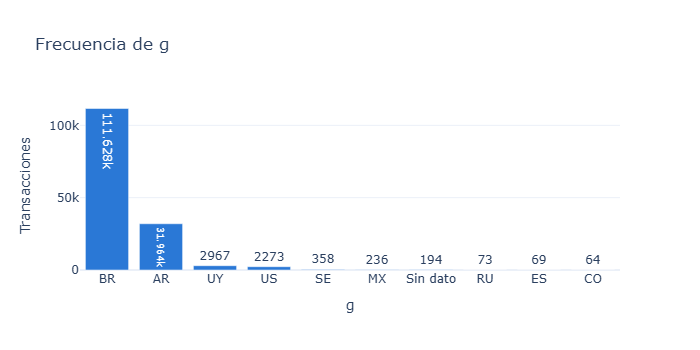

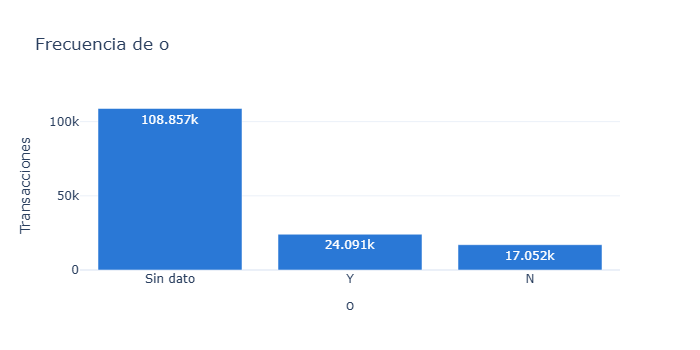

Resorting to unclean kill browser.


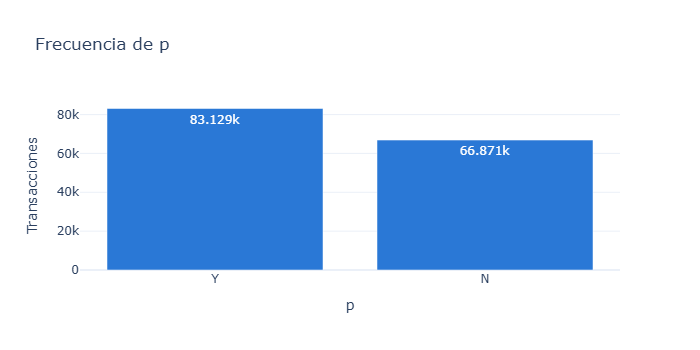

In [19]:
# Frecuencia de las categóricas de baja cardinalidad (en g, los 10 países principales)
for columna in ['g', 'o', 'p']:
    fig = px.bar(
        df[columna].fillna('Sin dato').value_counts().head(10),
        text_auto=True,
        color_discrete_sequence=[COLOR_PRINCIPAL],
        labels={columna: columna, 'value': 'Transacciones'},
        title=f'Frecuencia de {columna}',
    )
    fig.update_layout(showlegend=False, height=350)
    fig.show()

**💡 Hallazgos**

- `g` parece ser el **país**: Brasil (74%) y Argentina (21%) concentran el 95% de las transacciones, y el resto se reparte en una cola larga de 49 países, muchos con una sola transacción. Para modelar conviene agrupar los países poco frecuentes en una categoría "Otros".
- `j` tiene **8.324 categorías**, así que one-hot encoding no es viable. Habrá que usar frequency/target encoding o descartarla.
- `o` se reparte en nulo (72,6%), `Y` (16,1%) y `N` (11,4%). `p` es binaria y está relativamente balanceada (55% `Y`, 45% `N`).
- `fecha` tiene casi un valor único por fila: es un timestamp, no una categórica.

In [20]:
# Rango temporal que cubren las transacciones
fechas = pd.to_datetime(df['fecha'])
fechas.agg(['min', 'max'])

min   2020-03-08 00:02:15
max   2020-04-21 23:59:56
Name: fecha, dtype: datetime64[us]

Resorting to unclean kill browser.


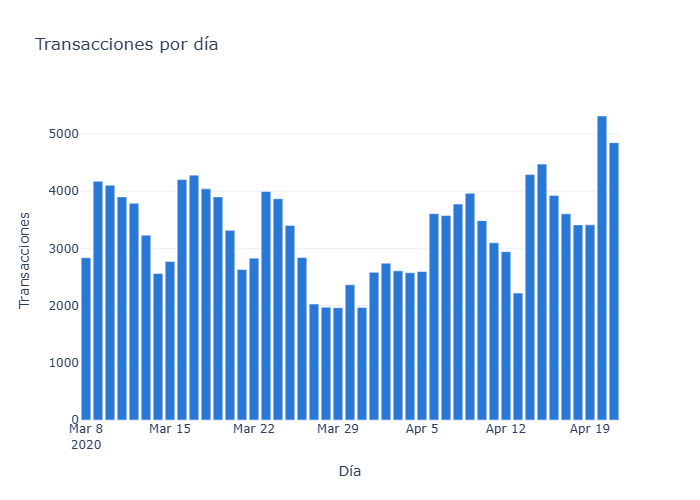

In [21]:
# Volumen de transacciones por día
transacciones_por_dia = fechas.dt.floor('D').value_counts().sort_index()

fig = px.bar(
    transacciones_por_dia,
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'fecha': 'Día', 'value': 'Transacciones'},
    title='Transacciones por día',
)
fig.update_layout(showlegend=False)
fig.show()

**💡 Hallazgos**

- Los datos cubren **45 días, del 8 de marzo al 21 de abril de 2020**, que coinciden con el inicio de las cuarentenas por COVID-19 en la región. Es un contexto atípico que puede no representar el comportamiento normal de compra.
- El volumen diario varía bastante, entre ~2.000 y ~5.300 transacciones.
- Con un rango tan corto no se puede capturar estacionalidad, pero sí hacer un **split temporal** (entrenar con las primeras semanas y validar con las últimas), que simula mejor la puesta en producción que un split aleatorio.

## **🔀 Relación con fraude**

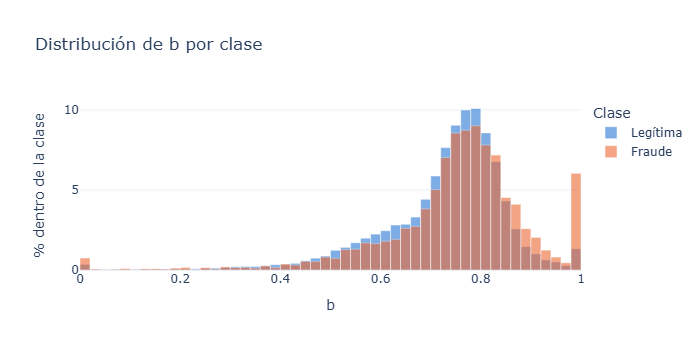

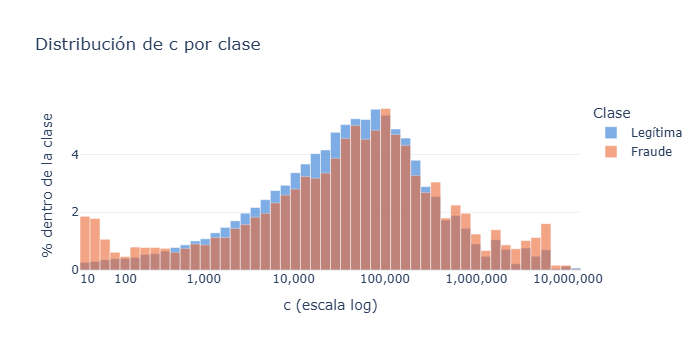

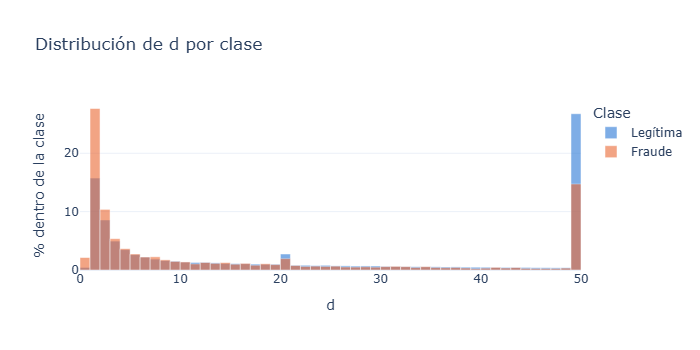

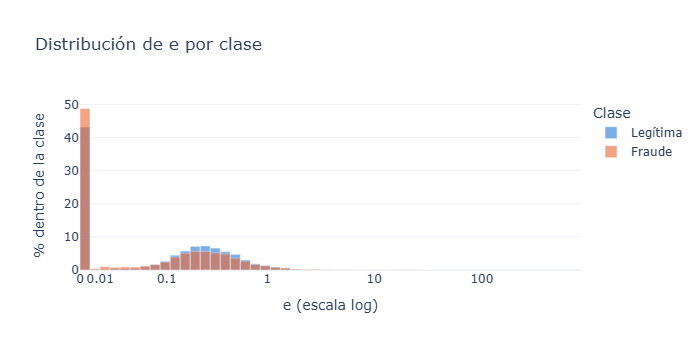

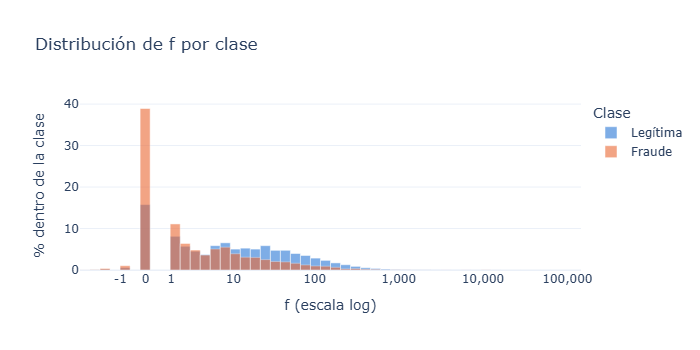

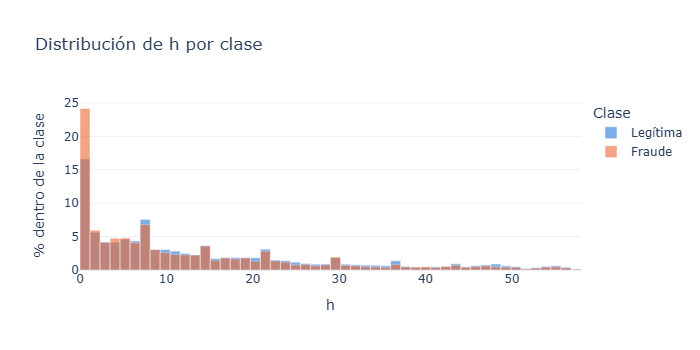

Resorting to unclean kill browser.


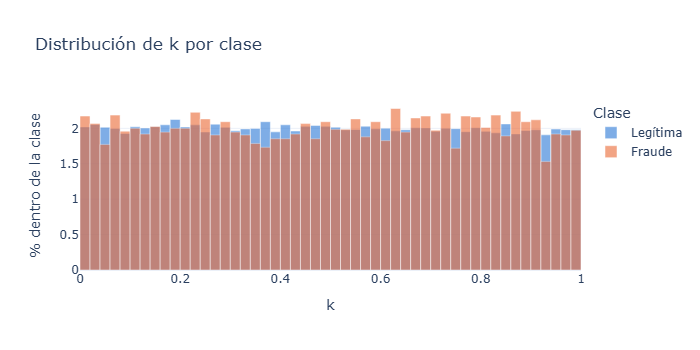

Resorting to unclean kill browser.


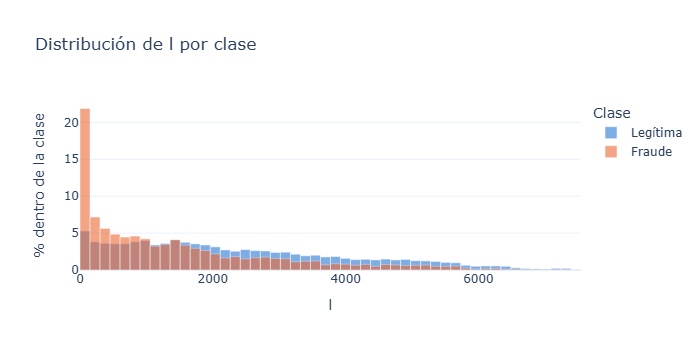

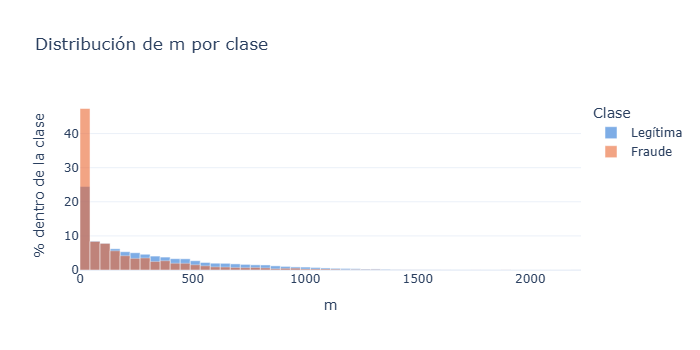

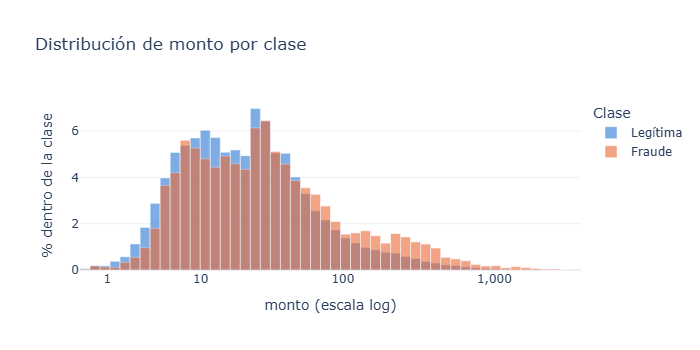

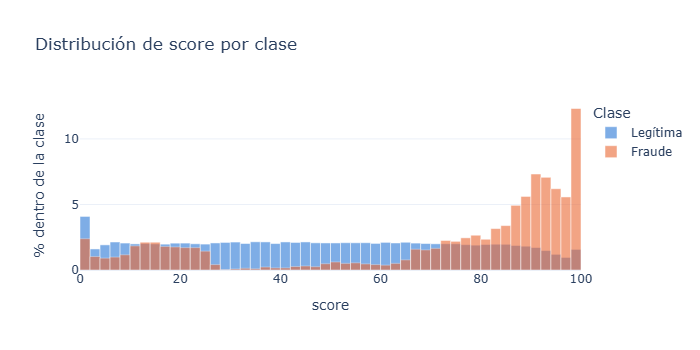

In [22]:
# Distribución de cada variable continua por clase, normalizada dentro de cada clase
clase = df['fraude'].map(ETIQUETAS_CLASE)

for columna in columnas_continuas:
    graficar_distribucion_por_clase(
        df[columna], clase, usar_log=columna in columnas_cola_larga
    ).show()

**💡 Hallazgos**

- `score` es la variable que **más separa las clases**: los fraudes se concentran entre 80 y 100, mientras que las transacciones legítimas se reparten de forma uniforme. Probablemente sea el score del sistema de prevención actual, así que sirve como feature y como **baseline** para comparar. Hay que confirmar que se calcula antes de la decisión y no con información posterior, para evitar data leakage.
- `f`, `l`, `m`, `d`, `e` y `h` toman **valores más bajos en los fraudes**. Si representan antigüedad o actividad de la cuenta, indicarían que el fraude se concentra en usuarios con poco historial.
- En `monto`, los fraudes tienen una **cola más pesada en montos altos** (por encima de ~100). Esto es clave para el negocio, porque cada fraude aprobado cuesta el 100% del monto.
- `k` y `c` casi no diferencian las clases.

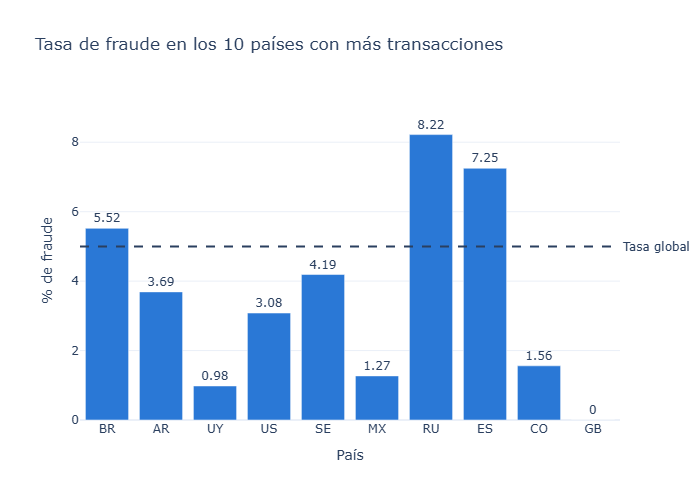

In [23]:
# Tasa de fraude en los 10 países con más transacciones, comparada con la tasa global
tasa_global = df['fraude'].mean() * 100
paises_principales = df['g'].value_counts().head(10).index
tasa_por_pais = (
    df[df['g'].isin(paises_principales)]
    .groupby('g')['fraude'].mean().mul(100).round(2)
    .reindex(paises_principales)
)

fig = px.bar(
    tasa_por_pais,
    text_auto=True,
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'g': 'País', 'value': '% de fraude'},
    title='Tasa de fraude en los 10 países con más transacciones',
)
fig.update_traces(textposition='outside')
fig.add_hline(y=tasa_global, line_dash='dash', annotation_text='Tasa global', annotation_position='right')
fig.update_layout(showlegend=False)
fig.show()

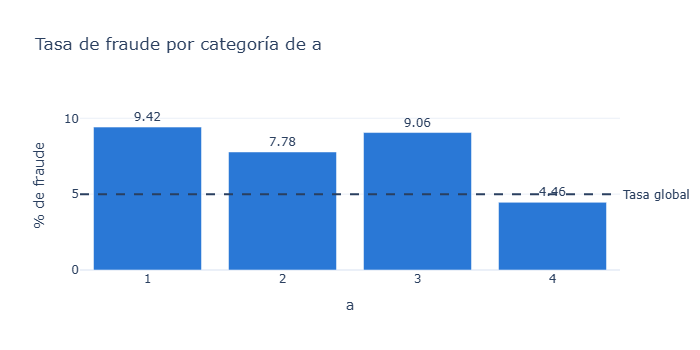

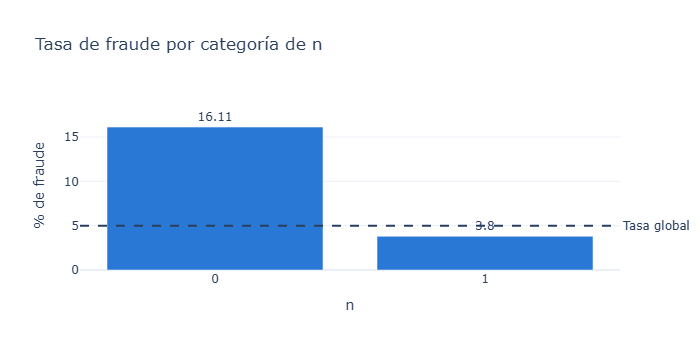

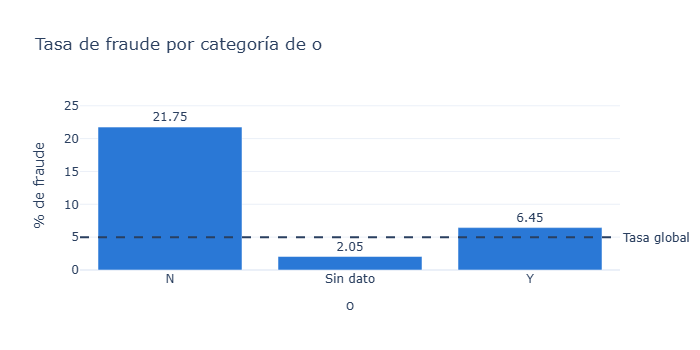

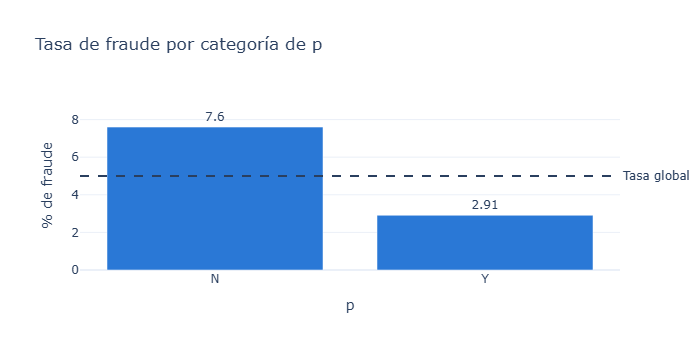

In [24]:
# Tasa de fraude por valor de las discretas y de o y p; los nulos se tratan como una categoría más
for columna in [*columnas_discretas, 'o', 'p']:
    tasa_por_categoria = (
        df.assign(categoria=df[columna].astype('string').fillna('Sin dato'))
        .groupby('categoria')['fraude'].mean().mul(100).round(2)
    )
    fig = px.bar(
        tasa_por_categoria,
        text_auto=True,
        color_discrete_sequence=[COLOR_PRINCIPAL],
        labels={'categoria': columna, 'value': '% de fraude'},
        title=f'Tasa de fraude por categoría de {columna}',
    )
    fig.update_traces(textposition='outside')
    fig.add_hline(y=tasa_global, line_dash='dash', annotation_text='Tasa global', annotation_position='right')
    fig.update_layout(showlegend=False, height=350)
    fig.show()

**💡 Hallazgos**

- `o` es muy informativa: con `N` la tasa de fraude es de **21,8%** (4 veces la global), con `Y` de 6,5%, y con el **nulo de solo 2,1%**. El nulo no es ruido sino la categoría más segura, así que conviene mantenerlo como categoría propia en lugar de imputarlo.
- `n = 0` tiene una tasa de fraude de 16,1% frente a 3,8% con `n = 1`, y `p = N` una de 7,6% frente a 2,9% con `p = Y`. En `a`, los valores 1–3 rondan 8–9% frente a 4,5% en `a = 4`. Las categorías minoritarias son las más riesgosas.
- Por país, Rusia (8,2%) y España (7,3%) superan la tasa global, mientras que Uruguay (1,0%) y México (1,3%) quedan muy por debajo. Brasil (5,5%) y Argentina (3,7%), que concentran el volumen, están cerca de la media. En los países pequeños las tasas son inestables por la poca cantidad de casos.

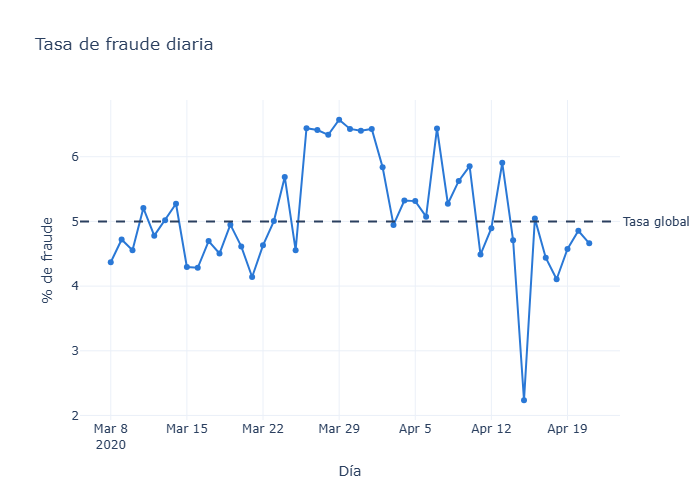

In [25]:
# Tasa de fraude diaria, para detectar cambios de comportamiento en el tiempo
tasa_por_dia = df.groupby(fechas.dt.floor('D'))['fraude'].mean().mul(100)

fig = px.line(
    tasa_por_dia,
    markers=True,
    color_discrete_sequence=[COLOR_PRINCIPAL],
    labels={'fecha': 'Día', 'value': '% de fraude'},
    title='Tasa de fraude diaria',
)
fig.add_hline(y=tasa_global, line_dash='dash', annotation_text='Tasa global', annotation_position='right')
fig.update_layout(showlegend=False)
fig.show()

**💡 Hallazgos**

- La tasa de fraude **no es estable en el tiempo**: oscila entre 2,2% (15 de abril) y 6,6% (29 de marzo), y entre el 26 de marzo y el 2 de abril se mantiene cerca de 6,5%.
- Esto refuerza dos decisiones: validar con un **split temporal** en lugar de uno aleatorio, y en producción **monitorear el drift** de la tasa de fraude y de las variables principales.